# **Automated Meshing**

Flow360 allows the use of Automated Meshing using the Python API. For this exercise, the ONERA M6 Wing case will be used as an example. 
The geometry is built in Engineering Sketch Pad (ESP) and will be submitted using the Python API to generate mesh and run the simulation.

For details about Engineering Sketch Pad, visit this section of the documentation about [ESP](https://docs.flexcompute.com/projects/flow360/en/latest/preprocessing/InstallESP/InstallESP.html#espinstallation).

<center><img src="https://docs.flexcompute.com/projects/flow360/en/latest/_images/om6Model.png"/></center>

The flow conditions for this case are:
- Reynolds number = 14.6e+06
- Mach number = 0.84
- Angle of Attack = 3.06°

## Imports

To upload the geometry file, we first need to import Flow360 and OM6wing class.

In [1]:
# Flow360 imports
import flow360 as fl
from flow360.examples import OM6wing

# We also import and change the log settings to only see ones of level INFO or higher
from flow360.log import log, set_logging_level

log.log_to_file = False
set_logging_level("INFO")

We can download the geometry file from the server using the `get_files()` method.

In [2]:
OM6wing.get_files()

You can also download the geometry file directly from [here](https://simcloud-public-1.s3.amazonaws.com/om6QuickStartAutoMesh/om6wing.csm).

## Project Creation
In order to run a simulation, we need to create project, where all the information about geometry, surface mesh, volume mesh and case will be contained.

In [3]:
project = fl.Project.from_file(OM6wing.geometry, name="Automated Meshing Quick Start")

Output()

[10:03:24] INFO: Geometry successfully submitted:                                                                  
                   name   = Automated Meshing Quick Start                                                          
                   id     = geo-63a082b4-b2c8-4497-b5b5-62885bc02ac1                                               
                   status = uploaded                                                                               
           

           INFO: Waiting for geometry to be processed.

[10:03:58] WARNING: Could not find face grouping info in the draft's simulation settings. Please remember to group 
           them if relevant features are used.

           WARNING: Could not find edge grouping info in the draft's simulation settings. Please remember to group 
           them if relevant features are used.

Creating a `geometry` variable will help us in setting up mesh refinements and boundary conditions.

In [4]:
geometry = project.geometry

We now have to group the faces and edges. First, we can check the available groupings.

In [5]:
geometry.show_available_groupings()

[10:04:06] INFO:  >> Available attribute tags for grouping **faces**:

           INFO:     >> Tag 0: faceName. Grouping with this tag results in:

           INFO:         >> Group 0: wing

           INFO:     >> Tag 1: groupName. Grouping with this tag results in:

           INFO:         >> Group 0: wing

...

           INFO:         >> Group 1: tipAirfoilEdge

           INFO:         >> Group 2: wingLeadingEdge

           INFO:         >> Group 3: rootAirfoilEdge

           INFO:         >> Group 4: body0001_edge0008

           INFO:         >> Group 5: body0001_edge0010

Now we can group them with

In [6]:
geometry.group_edges_by_tag("edgeName")
geometry.group_faces_by_tag("faceName")

Another option create a project is to use a file of your choice by using:

`project = fl.Project.from_file("my_geometry_file.csm", name="Quick Start")`

Here, `my_geometry_file.csm` is a geometry file that you would like to use in your simulation.

## Setting up simulation parameters
We define inputs of the `SimulationParams`, which will be later used to run the case.

In [7]:
# Use SI units
with fl.SI_unit_system:

    # Cylinder entities for mesh refinement
    cylinders = [
        fl.Cylinder(
            name=f"cylinder{i+1}",
            axis=[0, 1, 0],
            center=[0.7, -1, 0],
            outer_radius=outer_radius,
            height=2,
        )
        for i, outer_radius in enumerate([1.1, 2.2, 3.3, 4.5])
    ]
    cylinder5 = fl.Cylinder(
        name="cylinder5", axis=[-1, 0, 0], center=[2, -1, 0], outer_radius=6.5, height=14.5
    )

    # Farfield entity for volume zones and boundary conditions
    farfield = fl.AutomatedFarfield(name="farfield")

    # Simulation parameters
    params = fl.SimulationParams(
        # Meshing parameters
        meshing=fl.MeshingParams(
            # Default meshing settings
            defaults=fl.MeshingDefaults(
                surface_edge_growth_rate=1.07,
                surface_max_edge_length=0.15,
                curvature_resolution_angle=10 * fl.u.deg,
                boundary_layer_first_layer_thickness=1.35e-6,
                boundary_layer_growth_rate=1.04,
            ),
            # Generate finer mesh in refinement regions and boundary layer
            refinement_factor=1.45,
            # New volume zones
            volume_zones=[farfield],
            # Local settings for refining the mesh
            refinements=[
                # Settings for growing anisotropic layers orthogonal to the specified edges
                fl.SurfaceEdgeRefinement(
                    edges=[geometry["wingLeadingEdge"], geometry["wingTrailingEdge"]],
                    method=fl.HeightBasedRefinement(value=3e-4),
                ),
                fl.SurfaceEdgeRefinement(
                    edges=[geometry["rootAirfoilEdge"], geometry["tipAirfoilEdge"]],
                    method=fl.ProjectAnisoSpacing(),
                ),
                # Settings for refining surface elements of given surfaces
                fl.SurfaceRefinement(faces=[geometry["wing"]], max_edge_length=0.15),
                # Settings for uniform spacing refinement inside specified regions of mesh
                fl.UniformRefinement(name="refinement1", spacing=0.075, entities=[cylinders[0]]),
                fl.UniformRefinement(name="refinement2", spacing=0.1, entities=[cylinders[1]]),
                fl.UniformRefinement(name="refinement3", spacing=0.175, entities=[cylinders[2]]),
                fl.UniformRefinement(name="refinement4", spacing=0.225, entities=[cylinders[3]]),
                fl.UniformRefinement(name="refinement5", spacing=0.3, entities=[cylinder5]),
            ],
        ),
        # Specify reference geometry values
        reference_geometry=fl.ReferenceGeometry(
            area=1.15315084119231,
            moment_center=[0, 0, 0],
            moment_length=[1.47602, 0.801672958512342, 1.47602],
        ),
        # Assign operating condition in the freestream
        operating_condition=fl.operating_condition_from_mach_reynolds(
            reynolds=14.6e6,
            mach=0.84,
            project_length_unit=fl.u.m,
            temperature=297.78,
            alpha=3.06 * fl.u.deg,
        ),
        # Set the simulation as steady and provide parameters
        time_stepping=fl.Steady(
            max_steps=5000, CFL=fl.RampCFL(initial=1, final=200, ramp_steps=2250)
        ),
        # Create models where boundary conditions and solver settings are specified
        models=[
            fl.Fluid(),
            fl.Wall(surfaces=[geometry["wing"]], name="NoSlipWall"),
            fl.SlipWall(surfaces=farfield.symmetry_planes, name="SlipWall"),
            fl.Freestream(surfaces=farfield.farfield, name="Freestream"),
        ],
        # Outputs for post-processing purposes
        outputs=[
            fl.SurfaceOutput(
                output_fields=["primitiveVars", "Cp", "Cf"], surfaces=[geometry["wing"]]
            ),
            fl.VolumeOutput(output_fields=["primitiveVars", "Mach"]),
        ],
    )

[10:04:12] INFO: using: SI unit system for unit inference.

           INFO: Density and viscosity were calculated based on input data, ThermalState will be automatically     
           created.

Now that we have our simulation parameters ready, we can proceed with generating the mesh. For more information about configuration parameters, visit [Solver Configuration](https://docs.flexcompute.com/projects/flow360/en/latest/solverConfiguration/solverConfiguration.html#solverconfiguration).

## Mesh generation

Instead of running the entire simulation in one go from geometry to results, we can start by generating the surface mesh and volume mesh.

In [8]:
project.generate_surface_mesh(params, name="Surface Mesh Quick Start")

The surface mesh will begin generating.

In [9]:
project.generate_volume_mesh(params, name="Volume Mesh Quick Start")

And next up the volume mesh will be created.

## Running the case

After generating the volume mesh, we can run the case for our project.

In [10]:
project.run_case(params, name="Case of Automated Meshing Quick Start")

To check the status of your case you can use the following:

In [11]:
project.case.status

<Flow360Status.PENDING: 'pending'>

## Post processing

When the case is calculated, we can post process the results.

In [12]:
case = project.case

# Wait for the case to finish
case.wait()

Download the results of the simulation.

In [13]:
nonlinear_residuals = case.results.nonlinear_residuals
nonlinear_residuals = nonlinear_residuals.as_dataframe()

cfl = case.results.cfl
cfl = cfl.as_dataframe()

total_forces = case.results.total_forces
total_forces = total_forces.as_dataframe()

Output()

[10:48:28] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmphh79tbg7/0373a2ea-8795-4f19-9dda-5fdc650430e4.csv

Output()

[10:48:30] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmphh79tbg7/1cc61241-12f5-4b0e-8188-522056b6ad6e.csv

Output()

[10:48:31] INFO: Saved to                                                                                          
           /var/folders/qk/mywsrvps5gl_f3yjx2k1v1xm0000gn/T/tmphh79tbg7/18fcac64-6ebb-426c-a293-42f79b22cd42.csv

Plotting the non-linear residuals can help visualize convergence of the solution.

<Axes: xlabel='Pseudo Step', ylabel='residuals'>

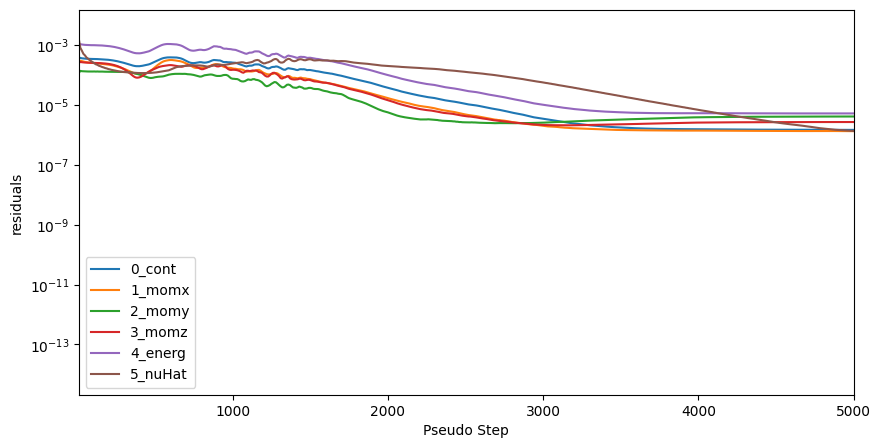

In [14]:
nonlinear_residuals.plot(
    x="pseudo_step",
    y=["0_cont", "1_momx", "2_momy", "3_momz", "4_energ", "5_nuHat"],
    logy=True,
    xlim=(10, 5000),
    xlabel="Pseudo Step",
    ylabel="residuals",
    figsize=(10, 5),
)

We can also plot CFL values of both the Navier-Stokes solver and turbulence solver.

<Axes: xlabel='pseudo_step'>

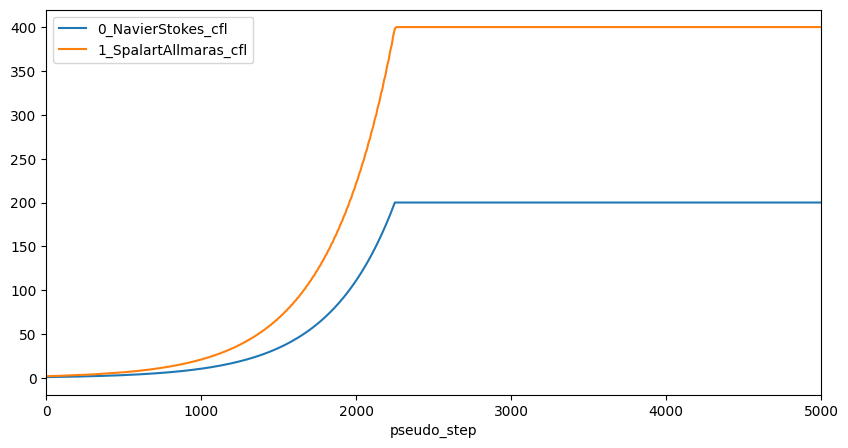

In [15]:
cfl.plot(
    x="pseudo_step",
    y=["0_NavierStokes_cfl", "1_SpalartAllmaras_cfl"],
    xlim=(0, 5000),
    figsize=(10, 5),
)

Finally we will take a look a how forces changed throught the calculation of the simulation.

array([<Axes: xlabel='Pseudo Step'>, <Axes: xlabel='Pseudo Step'>,
       <Axes: xlabel='Pseudo Step'>], dtype=object)

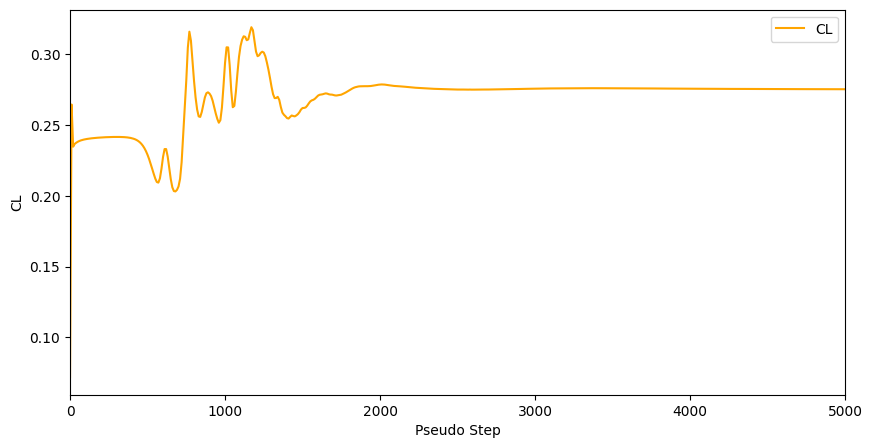

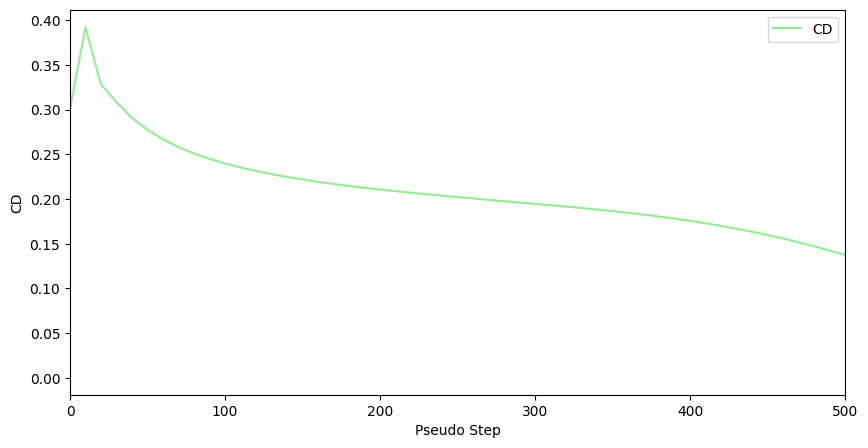

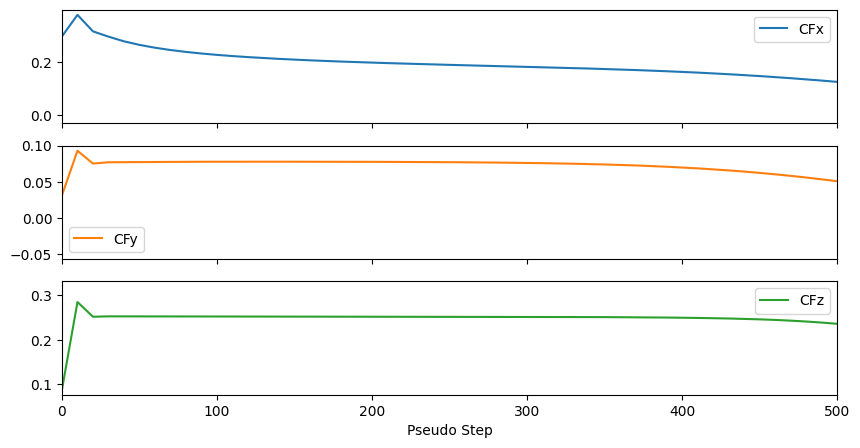

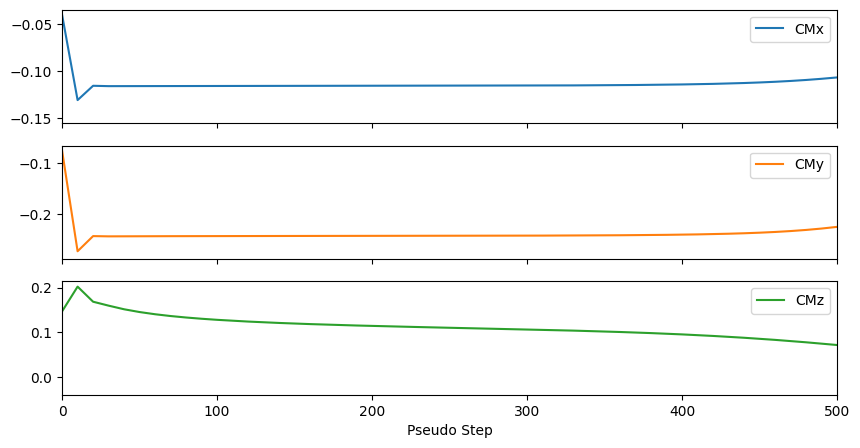

In [16]:
total_forces.plot(
    x="pseudo_step",
    y="CL",
    xlabel="Pseudo Step",
    ylabel="CL",
    xlim=(0, 5000),
    figsize=(10, 5),
    style="orange",
)
total_forces.plot(
    x="pseudo_step",
    y="CD",
    xlabel="Pseudo Step",
    ylabel="CD",
    xlim=(0, 500),
    figsize=(10, 5),
    style="lightgreen",
)
total_forces.plot(
    x="pseudo_step",
    y=["CFx", "CFy", "CFz"],
    xlabel="Pseudo Step",
    xlim=(0, 500),
    figsize=(10, 5),
    subplots=True,
)
total_forces.plot(
    x="pseudo_step",
    y=["CMx", "CMy", "CMz"],
    xlabel="Pseudo Step",
    xlim=(0, 500),
    figsize=(10, 5),
    subplots=True,
)

For more information about this Quick Start case, visity the [Flow360 documentation](https://docs.flexcompute.com/projects/flow360/en/latest/quickStart/PythonAPI_AutomatedMeshing/PythonAPI_AutomatedMeshing.html).